# Notebook 03 - LSTM Training

**Kelompok 08 - Kecerdasan Buatan 02**

| NPM | Nama |
|-----|------|
| 2306242395 | Calvin Wirathama Katoroy |
| 2306220532 | Syahmi Hamdani |
| 2306220323 | Christover Angelo |
| 2306221024 | Matthew Immanuel |

**Tujuan:** Melatih model LSTM sebagai main model dengan 6 eksperimen hyperparameter (hidden_size, num_layers, dropout, seq_len). History training disimpan ke Drive bersama checkpoint agar loss curve tersedia di sesi Colab berikutnya.

In [20]:
import subprocess, os
from pathlib import Path

REPO_URL  = 'https://github.com/calvinkatoroy/tugas-akhir-ai-kel-08.git'
REPO_NAME = 'tugas-akhir-ai-kel-08'

cwd = Path.cwd()

if (cwd / '../src').resolve().exists():
    result = subprocess.run(['git', '-C', str((cwd / '..').resolve()), 'pull'],
                            capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')

elif (cwd / 'src').exists():
    result = subprocess.run(['git', 'pull'], capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')
    os.chdir('notebooks')

else:
    repo_path = cwd / REPO_NAME
    if not repo_path.exists():
        print(f'Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    else:
        print('Repo found, pulling latest...')
        subprocess.run(['git', '-C', str(repo_path), 'pull'], capture_output=True)
    os.chdir(repo_path / 'notebooks')

print(f'Working dir: {Path.cwd()}')

Already up to date.
Working dir: /content/tugas-akhir-ai-kel-08/notebooks


In [21]:
import sys
sys.path.insert(0, '..')

import warnings, random, copy
import numpy as np
import torch
import yaml
from pathlib import Path

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
    print('Mixed precision: ON (autocast + GradScaler)')

def safe_log_experiment(record, csv_path):
    import os, pandas as pd
    from pathlib import Path
    path = Path(csv_path)
    if path.exists():
        try:
            pd.read_csv(path)
        except Exception:
            print(f'WARNING: corrupt CSV at {path}, resetting.')
            os.remove(path)
    from src.utils import log_experiment
    log_experiment(record, csv_path=csv_path)


Device: cpu


In [22]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/tugas-akhir-ai")
    SPLITS_DIR = DRIVE_ROOT / "splits"
else:
    import yaml
    with open("../config.yaml") as f:
        _cfg = yaml.safe_load(f)
    DRIVE_ROOT = Path(_cfg["data"]["drive_root"])
    SPLITS_DIR = Path(_cfg["data"]["splits_drive"])

print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"SPLITS_DIR: {SPLITS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT: /content/drive/MyDrive/tugas-akhir-ai
SPLITS_DIR: /content/drive/MyDrive/tugas-akhir-ai/splits


In [23]:
with open("../config.yaml") as f:
    cfg = yaml.safe_load(f)

X_train = np.load(SPLITS_DIR / "X_train_seq.npy")
y_train = np.load(SPLITS_DIR / "y_train_seq.npy")
X_val   = np.load(SPLITS_DIR / "X_val_seq.npy")
y_val   = np.load(SPLITS_DIR / "y_val_seq.npy")
X_test  = np.load(SPLITS_DIR / "X_test_seq.npy")
y_test  = np.load(SPLITS_DIR / "y_test_seq.npy")

n_features = X_train.shape[2]
seq_len    = X_train.shape[1]
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"n_features={n_features}, seq_len={seq_len}")

Train: (301950, 10, 16)  Val: (64696, 10, 16)  Test: (64698, 10, 16)
n_features=16, seq_len=10


## Baseline run (config defaults)

In [24]:
from src.models.lstm_model import build_lstm
from src.train import train_model
from src.utils import log_experiment

model = build_lstm(cfg, n_features)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

LSTMClassifier(
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
Trainable parameters: 215,234


In [25]:
import os, shutil, json

_ckpt_local = '../results/checkpoints/best_lstm.pt'
_ckpt_drive = str(DRIVE_ROOT / 'best_lstm.pt')
_hist_local = '../results/checkpoints/history_lstm_01.json'
_hist_drive = str(DRIVE_ROOT / 'history_lstm_01.json')

os.makedirs('../results/checkpoints', exist_ok=True)
if not os.path.exists(_ckpt_local) and os.path.exists(_ckpt_drive):
    shutil.copy(_ckpt_drive, _ckpt_local)
    print('Restored best_lstm.pt from Drive')
    if os.path.exists(_hist_drive):
        shutil.copy(_hist_drive, _hist_local)
        print('Restored history from Drive')

if os.path.exists(_ckpt_local):
    print('Checkpoint found - skipping baseline training.')
    if os.path.exists(_hist_local):
        with open(_hist_local) as f:
            history_baseline = json.load(f)
        print('History loaded.')
    elif os.path.exists(_hist_drive):
        with open(_hist_drive) as f:
            history_baseline = json.load(f)
        print('History loaded from Drive.')
    else:
        history_baseline = {'val_f1': [0.0], 'train_loss': [], 'val_loss': []}
        print('No saved history - loss curve unavailable this session.')
else:
    history_baseline, ckpt_baseline = train_model(
        model, X_train, y_train, X_val, y_val,
        cfg=cfg, model_key='lstm',
        checkpoint_dir='../results/checkpoints',
    )
    with open(_hist_local, 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in history_baseline.items()}, f)
    shutil.copy(_hist_local, _hist_drive)
    print('History saved to Drive.')
    safe_log_experiment({
        'exp_id': 'lstm_01_baseline',
        'model': 'LSTM',
        'hidden_size': cfg['lstm']['hidden_size'],
        'num_layers': cfg['lstm']['num_layers'],
        'dropout': cfg['lstm']['dropout'],
        'seq_len': cfg['lstm']['seq_len'],
        'lr': cfg['lstm']['learning_rate'],
        'batch_size': cfg['lstm']['batch_size'],
        'best_val_f1': round(max(history_baseline['val_f1']), 4),
        'notes': 'baseline - config defaults',
    }, csv_path=str(DRIVE_ROOT / 'metrics_summary.csv'))


Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0524 acc=0.9815 | val_loss=0.0291 acc=0.9912 f1=0.9943 | 230.7s
  Epoch  10/50 | train_loss=0.0154 acc=0.9956 | val_loss=0.0160 acc=0.9948 f1=0.9966 | 233.5s
  Epoch  20/50 | train_loss=0.0109 acc=0.9966 | val_loss=0.0160 acc=0.9961 f1=0.9975 | 236.8s
  Epoch  30/50 | train_loss=0.0078 acc=0.9973 | val_loss=0.0198 acc=0.9957 f1=0.9972 | 233.6s
  Epoch  40/50 | train_loss=0.0063 acc=0.9978 | val_loss=0.0243 acc=0.9958 f1=0.9973 | 234.0s
  Epoch  50/50 | train_loss=0.0059 acc=0.9980 | val_loss=0.0265 acc=0.9957 f1=0.9972 | 236.8s
  Best val F1: 0.9976 — checkpoint: ../results/checkpoints/best_lstm.pt
History saved to Drive.


## Hyperparameter Experiments
Document at least 5 runs. Change ONE hyperparam at a time.

In [9]:
def run_lstm_experiment(exp_id, overrides, notes=''):
    """overrides: dict of cfg['lstm'] keys to override."""
    exp_cfg = copy.deepcopy(cfg)
    exp_cfg['lstm'].update(overrides)

    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    if torch.cuda.is_available(): torch.cuda.empty_cache()
    m = build_lstm(exp_cfg, n_features)
    hist, ckpt = train_model(
        m, X_train, y_train, X_val, y_val,
        cfg=exp_cfg, model_key='lstm',
        checkpoint_dir='../results/checkpoints',
    )
    best_f1 = round(max(hist['val_f1']), 4)
    safe_log_experiment({
        'exp_id': exp_id,
        'model': 'LSTM',
        'hidden_size': exp_cfg['lstm']['hidden_size'],
        'num_layers': exp_cfg['lstm']['num_layers'],
        'dropout': exp_cfg['lstm']['dropout'],
        'seq_len': exp_cfg['lstm']['seq_len'],
        'lr': exp_cfg['lstm']['learning_rate'],
        'batch_size': exp_cfg['lstm']['batch_size'],
        'best_val_f1': best_f1,
        'notes': notes,
    }, csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))
    print(f'[{exp_id}] best_val_f1={best_f1}')
    return hist, ckpt, best_f1

In [8]:
# Exp 02 - smaller hidden size
hist_02, ckpt_02, f1_02 = run_lstm_experiment(
    'lstm_02_hidden64', {'hidden_size': 64}, 'hidden_size=64')

Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0562 acc=0.9793 | val_loss=0.0357 acc=0.9895 f1=0.9932 | 53.7s
  Epoch  10/50 | train_loss=0.0167 acc=0.9954 | val_loss=0.0154 acc=0.9958 f1=0.9973 | 51.1s
  Epoch  20/50 | train_loss=0.0137 acc=0.9960 | val_loss=0.0143 acc=0.9960 f1=0.9974 | 52.4s
  Epoch  30/50 | train_loss=0.0097 acc=0.9971 | val_loss=0.0149 acc=0.9958 f1=0.9973 | 52.3s
  Epoch  40/50 | train_loss=0.0082 acc=0.9974 | val_loss=0.0184 acc=0.9961 f1=0.9974 | 52.5s
  Epoch  50/50 | train_loss=0.0081 acc=0.9975 | val_loss=0.0189 acc=0.9959 f1=0.9974 | 53.0s
  Best val F1: 0.9977 — checkpoint: ../results/checkpoints/best_lstm.pt
[lstm_02_hidden64] best_val_f1=0.9977


In [9]:
# Exp 03 - larger hidden size
hist_03, ckpt_03, f1_03 = run_lstm_experiment(
    'lstm_03_hidden256', {'hidden_size': 256}, 'hidden_size=256')

Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0520 acc=0.9824 | val_loss=0.0319 acc=0.9902 f1=0.9937 | 61.7s
  Epoch  10/50 | train_loss=0.0168 acc=0.9956 | val_loss=0.0171 acc=0.9953 f1=0.9970 | 61.9s
  Epoch  20/50 | train_loss=0.0107 acc=0.9969 | val_loss=0.0177 acc=0.9960 f1=0.9974 | 61.8s
  Epoch  30/50 | train_loss=0.0069 acc=0.9978 | val_loss=0.0268 acc=0.9958 f1=0.9973 | 61.1s
  Epoch  40/50 | train_loss=0.0039 acc=0.9987 | val_loss=0.0399 acc=0.9956 f1=0.9972 | 62.2s
  Epoch  50/50 | train_loss=0.0030 acc=0.9990 | val_loss=0.0475 acc=0.9956 f1=0.9972 | 61.3s
  Best val F1: 0.9975 — checkpoint: ../results/checkpoints/best_lstm.pt
[lstm_03_hidden256] best_val_f1=0.9975


In [10]:
# Exp 04 - 3 layers
hist_04, ckpt_04, f1_04 = run_lstm_experiment(
    'lstm_04_layers3', {'num_layers': 3}, 'num_layers=3')

Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0578 acc=0.9780 | val_loss=0.0344 acc=0.9904 f1=0.9938 | 62.2s
  Epoch  10/50 | train_loss=0.0178 acc=0.9954 | val_loss=0.0201 acc=0.9936 f1=0.9959 | 62.3s
  Epoch  20/50 | train_loss=0.0146 acc=0.9960 | val_loss=0.0199 acc=0.9946 f1=0.9965 | 62.6s
  Epoch  30/50 | train_loss=0.0106 acc=0.9971 | val_loss=0.0179 acc=0.9961 f1=0.9975 | 62.6s
  Epoch  40/50 | train_loss=0.0088 acc=0.9974 | val_loss=0.0231 acc=0.9960 f1=0.9974 | 62.1s
  Epoch  50/50 | train_loss=0.0072 acc=0.9977 | val_loss=0.0266 acc=0.9957 f1=0.9972 | 62.0s
  Best val F1: 0.9976 — checkpoint: ../results/checkpoints/best_lstm.pt
[lstm_04_layers3] best_val_f1=0.9976


In [11]:
# Exp 05 - higher dropout
hist_05, ckpt_05, f1_05 = run_lstm_experiment(
    "lstm_05_dropout05", {"dropout": 0.5}, "dropout=0.5")

Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0601 acc=0.9780 | val_loss=0.0361 acc=0.9902 f1=0.9937 | 53.1s
  Epoch  10/50 | train_loss=0.0204 acc=0.9950 | val_loss=0.0170 acc=0.9956 f1=0.9972 | 53.5s
  Epoch  20/50 | train_loss=0.0164 acc=0.9958 | val_loss=0.0153 acc=0.9959 f1=0.9973 | 52.9s
  Epoch  30/50 | train_loss=0.0126 acc=0.9965 | val_loss=0.0162 acc=0.9960 f1=0.9974 | 53.4s
  Epoch  40/50 | train_loss=0.0099 acc=0.9969 | val_loss=0.0182 acc=0.9960 f1=0.9974 | 52.2s
  Epoch  50/50 | train_loss=0.0090 acc=0.9972 | val_loss=0.0198 acc=0.9958 f1=0.9973 | 53.3s
  Best val F1: 0.9974 — checkpoint: ../results/checkpoints/best_lstm.pt
[lstm_05_dropout05] best_val_f1=0.9974


In [12]:
# Exp 06 - shorter sequence window
# NOTE: requires rebuilding sequences at seq_len=5
# Load the flat splits and re-window
from src.preprocessing import make_sequences
import joblib

X_tr_flat = np.load(SPLITS_DIR / 'X_train.npy')
y_tr_flat = np.load(SPLITS_DIR / 'y_train.npy')
X_vl_flat = np.load(SPLITS_DIR / 'X_val.npy')
y_vl_flat = np.load(SPLITS_DIR / 'y_val.npy')

X_tr5, y_tr5 = make_sequences(X_tr_flat, y_tr_flat, seq_len=5)
X_vl5, y_vl5 = make_sequences(X_vl_flat, y_vl_flat, seq_len=5)

exp_cfg6 = copy.deepcopy(cfg)
exp_cfg6['lstm']['seq_len'] = 5
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
m6 = build_lstm(exp_cfg6, n_features)
hist_06, ckpt_06 = train_model(
    m6, X_tr5, y_tr5, X_vl5, y_vl5,
    cfg=exp_cfg6, model_key='lstm',
    checkpoint_dir='../results/checkpoints',
)
f1_06 = round(max(hist_06['val_f1']), 4)
safe_log_experiment({
    'exp_id': 'lstm_06_seqlen5',
    'model': 'LSTM',
    'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3,
    'seq_len': 5, 'lr': 0.001, 'batch_size': cfg['lstm']['batch_size'],
    'best_val_f1': f1_06, 'notes': 'seq_len=5',
}, csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))
print(f'[lstm_06_seqlen5] best_val_f1={f1_06}')

Training LSTM:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0532 acc=0.9812 | val_loss=0.0307 acc=0.9918 f1=0.9947 | 52.7s
  Epoch  10/50 | train_loss=0.0165 acc=0.9955 | val_loss=0.0162 acc=0.9951 f1=0.9968 | 52.8s
  Epoch  20/50 | train_loss=0.0117 acc=0.9967 | val_loss=0.0181 acc=0.9959 f1=0.9973 | 52.3s
  Epoch  30/50 | train_loss=0.0091 acc=0.9973 | val_loss=0.0232 acc=0.9957 f1=0.9972 | 51.3s
  Epoch  40/50 | train_loss=0.0081 acc=0.9975 | val_loss=0.0276 acc=0.9958 f1=0.9973 | 52.6s
  Epoch  50/50 | train_loss=0.0075 acc=0.9976 | val_loss=0.0294 acc=0.9957 f1=0.9972 | 52.1s
  Best val F1: 0.9974 — checkpoint: ../results/checkpoints/best_lstm.pt
[lstm_06_seqlen5] best_val_f1=0.9974


## Final Evaluation on Test Set

In [16]:
import pandas as pd

results = pd.read_csv(str(DRIVE_ROOT / 'metrics_summary.csv'))
lstm_results = results[results['model'] == 'LSTM'].copy()
avail_cols = [c for c in ['exp_id', 'hidden_size', 'num_layers', 'dropout', 'seq_len', 'lr', 'best_val_f1', 'notes'] if c in lstm_results.columns]
print(lstm_results[avail_cols])

best_row = lstm_results.loc[lstm_results['best_val_f1'].idxmax()]
print(f'\nBest: {best_row["exp_id"]}  val_F1={best_row["best_val_f1"]}')

_hist_map = {
    'lstm_01_baseline': history_baseline,
    'lstm_02_hidden64': hist_02,
    'lstm_03_hidden256': hist_03,
    'lstm_04_layers3': hist_04,
    'lstm_05_dropout05': hist_05,
    'lstm_06_seqlen5': hist_06,
}
best_history = _hist_map.get(best_row['exp_id'], history_baseline)
if not best_history.get('train_loss'):
    for _name in ['hist_02', 'hist_03', 'hist_04', 'hist_05', 'hist_06']:
        _h = globals().get(_name)
        if _h and _h.get('train_loss'):
            best_history = _h
            print(f'Using fallback history from {_name} (baseline not available).')
            break


              exp_id  hidden_size  num_layers  dropout  seq_len     lr  \
0   lstm_01_baseline          128           2      0.3       10  0.001   
1   lstm_02_hidden64           64           2      0.3       10  0.001   
2   lstm_01_baseline          128           2      0.3       10  0.001   
3   lstm_02_hidden64           64           2      0.3       10  0.001   
4  lstm_03_hidden256          256           2      0.3       10  0.001   
5    lstm_04_layers3          128           3      0.3       10  0.001   
6  lstm_05_dropout05          128           2      0.5       10  0.001   
7    lstm_06_seqlen5          128           2      0.3        5  0.001   

   best_val_f1                       notes  
0       0.9976  baseline - config defaults  
1       0.9976              hidden_size=64  
2       0.9974  baseline - config defaults  
3       0.9977              hidden_size=64  
4       0.9975             hidden_size=256  
5       0.9976                num_layers=3  
6       0.9974    

Checkpoint: hidden_size=128, num_layers=2

=== LSTM — Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



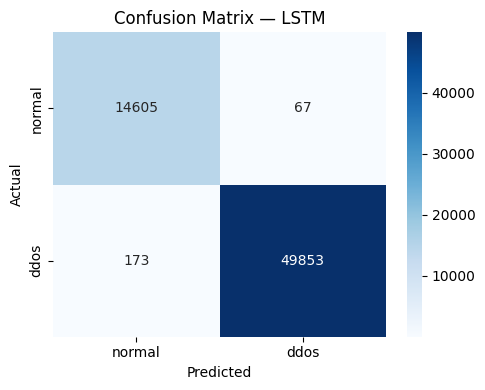

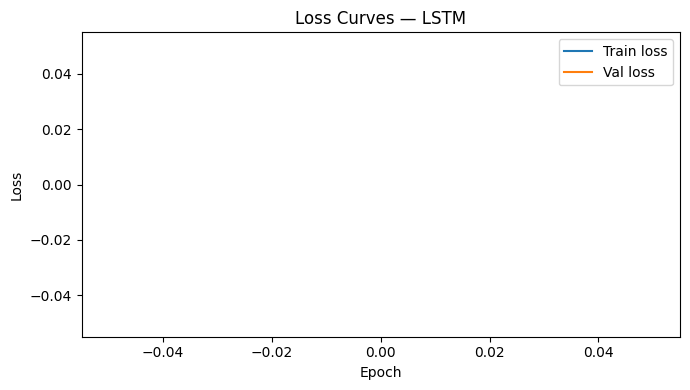

  FPR=0.0046  ROC-AUC=0.9996


In [27]:
import copy
from src.models.lstm_model import build_lstm
from src.evaluate import evaluate_dl_model
from src.utils import plot_loss_curves

# Auto-detect arch from checkpoint
_state = torch.load('../results/checkpoints/best_lstm.pt', map_location=device)
_h = _state['lstm.weight_ih_l0'].shape[0] // 4
_l = sum(1 for k in _state if k.startswith('lstm.weight_hh_l'))
print(f'Checkpoint: hidden_size={_h}, num_layers={_l}')

best_cfg = copy.deepcopy(cfg)
best_cfg['lstm']['hidden_size'] = _h
best_cfg['lstm']['num_layers']  = _l
best_cfg['lstm']['dropout']     = float(best_row['dropout'])

best_model = build_lstm(best_cfg, n_features).to(device)
best_model.load_state_dict(_state)
best_model.eval()

y_pred_lstm, y_prob_lstm = evaluate_dl_model(
    best_model, X_test, y_test,
    model_name='LSTM',
    history=best_history,
    figures_dir='../results/figures',
    csv_path=str(DRIVE_ROOT / 'metrics_summary.csv'),
)
np.save('../results/lstm_y_prob.npy', y_prob_lstm)
np.save('../results/y_test_seq.npy', y_test)


Using fallback history from history_baseline.


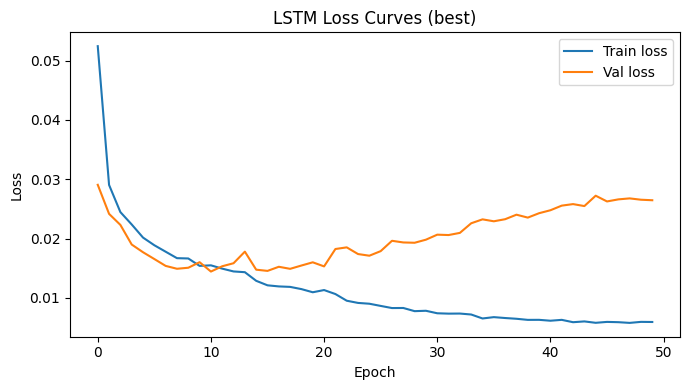

In [29]:
_plot_hist = best_history if best_history.get('train_loss') else None
if not _plot_hist:
    for _name in ['history_baseline', 'hist_02', 'hist_03', 'hist_04', 'hist_05', 'hist_06']:
        _h = globals().get(_name)
        if _h and _h.get('train_loss'):
            _plot_hist = _h
            print(f'Using fallback history from {_name}.')
            break

if _plot_hist:
    plot_loss_curves(
        _plot_hist['train_loss'], _plot_hist['val_loss'],
        title='LSTM Loss Curves (best)',
        save_path='../results/figures/loss_lstm.png',
    )
else:
    print('No training history available - skipping loss curve.')


In [30]:
import os, shutil
os.makedirs('../results/checkpoints', exist_ok=True)
_ckpt_drive = str(DRIVE_ROOT / 'best_lstm.pt')
_ckpt_local = '../results/checkpoints/best_lstm.pt'
if not os.path.exists(_ckpt_local):
    if os.path.exists(_ckpt_drive):
        shutil.copy(_ckpt_drive, _ckpt_local)
        print('Restored best_lstm.pt from Drive')
    else:
        print('ERROR: not found on Drive - check DRIVE_ROOT path')
else:
    print('Already exists locally')


Already exists locally


In [31]:
# Save best checkpoint to Drive so it persists across sessions
import shutil
shutil.copy("../results/checkpoints/best_lstm.pt", str(DRIVE_ROOT / "best_lstm.pt"))
print(f"Checkpoint saved to Drive: {DRIVE_ROOT / "best_lstm.pt"}")

Checkpoint saved to Drive: /content/drive/MyDrive/tugas-akhir-ai/best_lstm.pt
